# 06. 날짜 단위 Walk-forward OOF와 4-outcome 기대수익 최적화

`NO_FILL / TP / SL / TIMEOUT` 확률을 직접 학습하고, 각 fold의 과거 데이터에서만 추정한 가격대별 실현 payoff를 곱해 `predicted_expected_net_return`을 계산한다. 개발 6일의 expanding OOF에서만 threshold를 선택하고 2026-07-15~17 test에는 고정한다.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'AGENT.md').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다.')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.walk_forward_oof import run_experiment

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'python: {sys.executable}')

PROJECT_ROOT: /home/user/urbandatalab/YSLee/code/Detecting-entry-signals-for-short-term-trades-right-before-a-rapid-price-surge
python: /home/user/anaconda3/envs/urban/bin/python


## 1. Expanding walk-forward 학습

각 outer 평가일은 그보다 과거인 날짜만 사용한다. 직전 과거 날짜는 early stopping과 temperature calibration에 사용하며 outer 평가에는 참여하지 않는다. 최종 test 모델의 epoch와 temperature는 OOF fold에서만 정한다.

In [2]:
result = run_experiment(PROJECT_ROOT)
print(f"device: {result['device']}")
display(result['folds'])

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.w

device: cuda


,fold,fit_sessions,inner_validation_session,payoff_history_sessions,evaluation_session,best_epoch,temperature,inner_raw_logloss,inner_calibrated_logloss,train_rows_before_stride,train_rows_after_stride,inner_rows
0,1,"[session_2026-07-07, session_2026-07-08]",session_2026-07-09,"[session_2026-07-07, session_2026-07-08, sessi...",session_2026-07-10,21,1.025,0.853127,0.853040,9668,1939,6699
1,2,"[session_2026-07-07, session_2026-07-08, sessi...",session_2026-07-10,"[session_2026-07-07, session_2026-07-08, sessi...",session_2026-07-13,27,1.300,1.004303,0.987082,16367,3278,6859
2,3,"[session_2026-07-07, session_2026-07-08, sessi...",session_2026-07-13,"[session_2026-07-07, session_2026-07-08, sessi...",session_2026-07-14,23,1.200,0.976592,0.968928,23226,4652,5959


## 2. OOF·test 확률 및 기대수익 평가

In [3]:
metric_columns = [
    'evaluation_group', 'session', 'samples', 'multiclass_logloss', 'multiclass_brier',
    'macro_pr_auc', 'tp_positive_rate', 'tp_pr_auc', 'tp_roc_auc', 'tp_ece',
    'return_spearman', 'return_mae', 'top1_mean_actual_return', 'top5_mean_actual_return',
]
display(result['metrics'][metric_columns].set_index(['evaluation_group', 'session']))
display(result['payoffs'].query("fold == 'final'").set_index(['price_tier', 'outcome']))

samples  multiclass_logloss  \
evaluation_group session                                           
oof              ALL                   17465            0.981219   
test             ALL                   15180            0.883931   
oof              session_2026-07-10     6859            1.026700   
                 session_2026-07-13     5959            0.989335   
                 session_2026-07-14     4647            0.903680   
test             session_2026-07-15     6629            1.036413   
                 session_2026-07-16     4384            0.843605   
                 session_2026-07-17     4167            0.683785   

                                     multiclass_brier  macro_pr_auc  \
evaluation_group session                                              
oof              ALL                         0.545066      0.442331   
test             ALL                         0.495037      0.448628   
oof              session_2026-07-10          0.565773      0.410154   
                 session_2026-07-13          0.560149      0.412955   
                 session_2026-07-14          0.495162      0.495376   
test             session_2026-07-15          0.584268      0.425444   
                 session_2026-07-16          0.460399      0.459730   
                 session_2026-07-17          0.389526      0.427586   

                                     tp_positive_rate  tp_pr_auc  tp_roc_auc  \
evaluation_group session                                                       
oof              ALL                         0.068709   0.175486    0.785139   
test             ALL                         0.045257   0.141832    0.811832   
oof              session_2026-07-10          0.086456   0.187347    0.759285   
                 session_2026-07-13          0.057728   0.169411    0.799095   
                 session_2026-07-14          0.056596   0.179247    0.814456   
test             session_2026-07-15          0.057927   0.141644    0.765620   
                 session_2026-07-16          0.049954   0.151260    0.803027   
                 session_2026-07-17          0.020158   0.131451    0.881932   

                                       tp_ece  return_spearman  return_mae  \
evaluation_group session                                                     
oof              ALL                 0.007377         0.149853    0.012117   
test             ALL                 0.018982         0.159727    0.009601   
oof              session_2026-07-10  0.021525         0.151232    0.013546   
                 session_2026-07-13  0.011187         0.085009    0.010823   
                 session_2026-07-14  0.013855         0.217709    0.011668   
test             session_2026-07-15  0.021763         0.136706    0.012186   
                 session_2026-07-16  0.015986         0.201809    0.009715   
                 session_2026-07-17  0.017750         0.095489    0.005368   

                                     top1_mean_actual_return  \
evaluation_group session                                       
oof              ALL                               -0.002542   
test             ALL                               -0.006961   
oof              session_2026-07-10                -0.001989   
                 session_2026-07-13                -0.001223   
                 session_2026-07-14                -0.003922   
test             session_2026-07-15                -0.011841   
                 session_2026-07-16                -0.001286   
                 session_2026-07-17                -0.003846   

                                     top5_mean_actual_return  
evaluation_group session                                      
oof              ALL                               -0.000807  
test             ALL                               -0.001426  
oof              session_2026-07-10                -0.000621  
                 session_2026-07-13                -0.000961  
                 session_2026-07-14         

fold  history_samples  global_mean_return  \
price_tier    outcome                                               
below_1       NO_FILL  final             3997            0.000000   
              TP       final              845            0.046412   
              SL       final             2295           -0.033419   
              TIMEOUT  final             3749           -0.002586   
at_or_above_1 NO_FILL  final            15714            0.000000   
              TP       final             1002            0.046412   
              SL       final             2621           -0.033419   
              TIMEOUT  final             3609           -0.002586   

                       payoff_return  \
price_tier    outcome                  
below_1       NO_FILL       0.000000   
              TP            0.046047   
              SL           -0.033881   
              TIMEOUT      -0.003615   
at_or_above_1 NO_FILL       0.000000   
              TP            0.046725   
              SL           -0.033013   
              TIMEOUT      -0.001517   

                                                        history_sessions  
price_tier    outcome                                                     
below_1       NO_FILL  session_2026-07-07,session_2026-07-08,session_...  
              TP       session_2026-07-07,session_2026-07-08,session_...  
              SL       session_2026-07-07,session_2026-07-08,session_...  
              TIMEOUT  session_2026-07-07,session_2026-07-08,session_...  
at_or_above_1 NO_FILL  session_2026-07-07,session_2026-07-08,session_...  
              TP       session_2026-07-07,session_2026-07-08,session_...  
              SL       session_2026-07-07,session_2026-07-08,session_...  
              TIMEOUT  session_2026-07-07,session_2026-07-08,session_...

## 3. OOF 전용 threshold와 고정 test 결과

OOF 3개 평가일 모두 최소 체결 수와 양수 평균 순수익률을 만족해야 `VALID`다. Test는 threshold 탐색에 사용하지 않는다.

In [4]:
display(result['selected_threshold'])
display(result['backtest_metrics'].set_index('evaluation_group'))
display(result['session_metrics'].set_index(['evaluation_group', 'session']))
display(result['deployment'])
display(result['threshold_search'].sort_values(
    ['meets_constraints', 'profitable_session_share', 'worst_session_mean_net_return'],
    ascending=False,
).head(10))

,selected_threshold,selection_status,oof_mean_net_return,oof_portfolio_return,oof_profit_factor,oof_filled_trades,oof_profitable_session_share,oof_worst_session_mean_net_return
0,0.001508,NO_VALID_THRESHOLD,-0.003217,-0.010285,0.834167,32,0.666667,-0.012009


,signals_above_threshold,ten_minute_signal_clusters,order_attempts,filled_trades,tp_trades,sl_trades,timeout_trades,tp_precision_given_fill,mean_net_return_per_fill,median_net_return_per_fill,net_return_on_deployed_capital,return_on_initial_capital,total_net_pnl,profit_factor,max_drawdown,skipped_same_symbol,skipped_position_limit,skipped_cash_limit,threshold,ending_cash,selection_status
evaluation_group,,,,,,,,,,,,,,,,,,,,,
oof,55,30,43,32,10,18,4,0.3125,-0.003217,-0.032979,-0.003214,-0.010285,-102.850206,0.834167,-0.025108,12,0,0,0.001508,9897.149794,NO_VALID_THRESHOLD
test,41,6,31,25,4,18,3,0.1600,-0.016497,-0.033078,-0.016497,-0.041258,-412.582655,0.340242,-0.045635,10,0,0,0.001508,9587.417345,NO_VALID_THRESHOLD


signals_above_threshold  \
evaluation_group session                                       
oof              session_2026-07-10                       27   
                 session_2026-07-13                        8   
                 session_2026-07-14                       20   
test             session_2026-07-15                       34   
                 session_2026-07-16                        0   
                 session_2026-07-17                        7   

                                     ten_minute_signal_clusters  \
evaluation_group session                                          
oof              session_2026-07-10                          15   
                 session_2026-07-13                           5   
                 session_2026-07-14                          10   
test             session_2026-07-15                           5   
                 session_2026-07-16                           0   
                 session_2026-07-17                           1   

                                     order_attempts  filled_trades  tp_trades  \
evaluation_group session                                                        
oof              session_2026-07-10              18             12          4   
                 session_2026-07-13               7              5          2   
                 session_2026-07-14              18             15          4   
test             session_2026-07-15              25             22          4   
                 session_2026-07-16               0              0          0   
                 session_2026-07-17               6              3          0   

                                     sl_trades  timeout_trades  \
evaluation_group session                                         
oof              session_2026-07-10          5               3   
                 session_2026-07-13          2               1   
                 session_2026-07-14         11               0   
test             session_2026-07-15         16               2   
                 session_2026-07-16          0               0   
                 session_2026-07-17          2               1   

                                     tp_precision_given_fill  \
evaluation_group session                                       
oof              session_2026-07-10                 0.333333   
                 session_2026-07-13                 0.400000   
                 session_2026-07-14                 0.266667   
test             session_2026-07-15                 0.181818   
                 session_2026-07-16                      NaN   
                 session_2026-07-17                 0.000000   

                                     mean_net_return_per_fill  \
evaluation_group session                                        
oof              session_2026-07-10                  0.001004   
                 session_2026-07-13                  0.013028   
                 session_2026-07-14                 -0.012009   
test             session_2026-07-15                 -0.016944   
                 session_2026-07-16                       NaN   
                 session_2026-07-17                 -0.013221   

                                     median_net_return_per_fill  \
evaluation_group session                                          
oof              session_2026-07-10                   -0.010791   
                 session_2026-07-13                    0.038467   
                 session_2026-07-14                   -0.033138   
test             session_2026-07-15                   -0.033084   
                 session_2026-07-16                         NaN   
                 session_2026-07-17                   -0.033000   

                                     net_return_on_deployed_capital  \
evaluation_group session                                              
oof              session_2026-07-10                        0.001030   
                 session_

,selection_status,oof_eligible,test_return_pass,test_sessions,test_profitable_sessions,test_profitable_session_share,test_worst_session_mean_net_return,deployment_status
0,NO_VALID_THRESHOLD,False,False,3,0,0.0,-0.016944,FAIL


,signals_above_threshold,ten_minute_signal_clusters,order_attempts,filled_trades,tp_trades,sl_trades,timeout_trades,tp_precision_given_fill,mean_net_return_per_fill,median_net_return_per_fill,net_return_on_deployed_capital,return_on_initial_capital,total_net_pnl,profit_factor,max_drawdown,skipped_same_symbol,skipped_position_limit,skipped_cash_limit,threshold,ending_cash,oof_sessions,min_session_filled_trades,profitable_sessions,profitable_session_share,worst_session_mean_net_return,meets_constraints
21,55,30,43,32,10,18,4,0.312500,-0.003217,-0.032979,-0.003214,-0.010285,-102.850206,0.834167,-0.025108,12,0,0,0.001508,9897.149794,3,5,2,0.666667,-0.012009,False
11,81,42,68,49,14,27,8,0.285714,-0.004595,-0.032944,-0.004602,-0.022541,-225.406264,0.760614,-0.032332,13,0,0,0.000415,9774.593736,3,10,1,0.333333,-0.007981,False
12,79,41,66,48,14,26,8,0.291667,-0.004000,-0.032941,-0.004006,-0.019221,-192.209806,0.788410,-0.029043,13,0,0,0.000526,9807.790194,3,9,1,0.333333,-0.007981,False
5,97,50,82,57,17,32,8,0.298246,-0.004395,-0.032956,-0.004403,-0.025082,-250.821166,0.773414,-0.038594,15,0,0,0.000220,9749.178834,3,12,1,0.333333,-0.008757,False
4,100,51,83,57,17,32,8,0.298246,-0.004395,-0.032956,-0.004403,-0.025085,-250.847599,0.773390,-0.038597,17,0,0,0.000190,9749.152401,3,12,1,0.333333,-0.008757,False
10,84,43,71,51,15,28,8,0.294118,-0.004148,-0.032944,-0.004152,-0.021166,-211.658388,0.782789,-0.030262,13,0,0,0.000399,9788.341612,3,11,1,0.333333,-0.009067,False
0,108,53,89,58,17,33,8,0.293103,-0.004891,-0.032956,-0.004891,-0.028345,-283.445134,0.751267,-0.041811,19,0,0,0.000000,9716.554866,3,12,1,0.333333,-0.009660,False
1,108,53,89,58,17,33,8,0.293103,-0.004891,-0.032956,-0.004891,-0.028345,-283.445134,0.751267,-0.041811,19,0,0,0.000012,9716.554866,3,12,1,0.333333,-0.009660,False
2,105,52,86,58,17,33,8,0.293103,-0.004891,-0.032956,-0.004891,-0.028345,-283.445134,0.751267,-0.041811,19,0,0,0.000040,9716.554866,3,12,1,0.333333,-0.009660,False
3,102,51,84,58,17,33,8,0.293103,-0.004891,-0.032956,-0.004899,-0.028401,-284.014412,0.750892,-0.041867,18,0,0,0.000112,9715.985588,3,12,1,0.333333,-0.009660,False


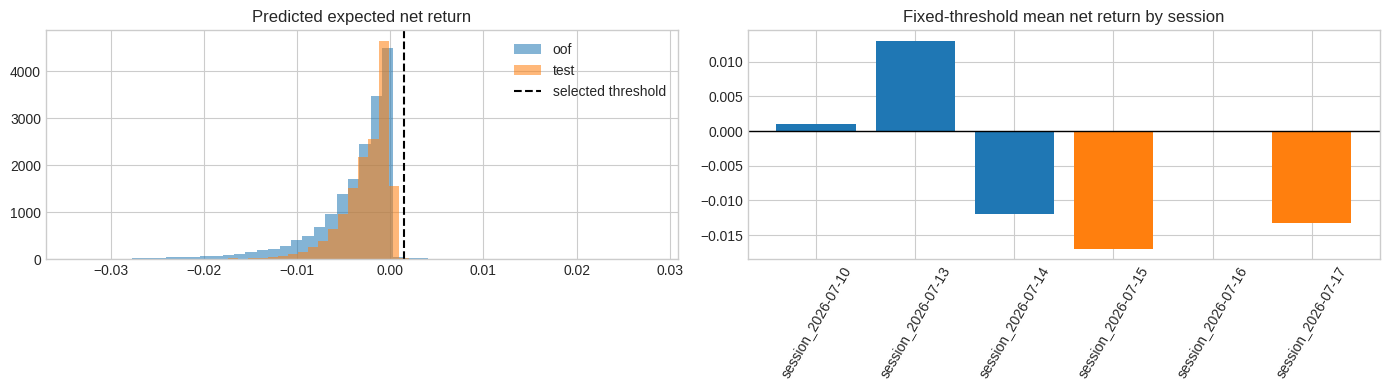

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for group, color in [('oof', 'tab:blue'), ('test', 'tab:orange')]:
    values = result['predictions'].loc[
        result['predictions']['evaluation_group'].eq(group), 'predicted_expected_net_return'
    ]
    axes[0].hist(values, bins=50, alpha=0.55, label=group, color=color)
session_plot = result['session_metrics'].copy()
axes[1].bar(session_plot['session'], session_plot['mean_net_return_per_fill'],
            color=session_plot['evaluation_group'].map({'oof': 'tab:blue', 'test': 'tab:orange'}))
axes[0].axvline(float(result['selected_threshold'].iloc[0]['selected_threshold']), color='black', linestyle='--', label='selected threshold')
axes[0].set_title('Predicted expected net return')
axes[0].legend()
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Fixed-threshold mean net return by session')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 4. Artifact와 결론

In [6]:
display(pd.DataFrame({
    'artifact': result['paths'].keys(),
    'path': [str(path) for path in result['paths'].values()],
    'size_kb': [path.stat().st_size / 1024 for path in result['paths'].values()],
}))
overall = result['metrics'].query("session == 'ALL'").set_index('evaluation_group')
selected = result['selected_threshold'].iloc[0]
deployment = result['deployment'].iloc[0]
findings = [
    f"**OOF:** 3개 날짜의 TP PR-AUC {overall.loc['oof', 'tp_pr_auc']:.4f}, expected-return Spearman {overall.loc['oof', 'return_spearman']:.4f}.",
    f"**Test:** 3개 날짜의 TP PR-AUC {overall.loc['test', 'tp_pr_auc']:.4f}, expected-return Spearman {overall.loc['test', 'return_spearman']:.4f}.",
    f"**Threshold:** OOF에서 {selected['selected_threshold']:.4%}를 선택했고 상태는 `{selected['selection_status']}`다.",
    f"**날짜 안정성:** test 양수 세션 {int(deployment['test_profitable_sessions'])}/{int(deployment['test_sessions'])}, 최종 판정 `{deployment['deployment_status']}`.",
    '**누수 방지:** test 7/15~17은 fold 학습, temperature, payoff, threshold 선택에 사용하지 않았다.',
]
display(Markdown('### 실행 결론\n\n' + '\n\n'.join(f'- {item}' for item in findings)))

,artifact,path,size_kb
0,predictions,/home/user/urbandatalab/YSLee/data/stock_data/...,1084.132812
1,metrics,/home/user/urbandatalab/YSLee/data/stock_data/...,10.336914
2,folds,/home/user/urbandatalab/YSLee/data/stock_data/...,8.641602
3,history,/home/user/urbandatalab/YSLee/data/stock_data/...,4.659180
4,payoffs,/home/user/urbandatalab/YSLee/data/stock_data/...,5.486328
5,threshold_search,/home/user/urbandatalab/YSLee/data/stock_data/...,21.069336
6,selected_threshold,/home/user/urbandatalab/YSLee/data/stock_data/...,5.942383
7,backtest_metrics,/home/user/urbandatalab/YSLee/data/stock_data/...,14.671875
8,session_metrics,/home/user/urbandatalab/YSLee/data/stock_data/...,14.918945
9,deployment,/home/user/urbandatalab/YSLee/data/stock_data/...,5.589844


### 실행 결론

- **OOF:** 3개 날짜의 TP PR-AUC 0.1755, expected-return Spearman 0.1499.

- **Test:** 3개 날짜의 TP PR-AUC 0.1418, expected-return Spearman 0.1597.

- **Threshold:** OOF에서 0.1508%를 선택했고 상태는 `NO_VALID_THRESHOLD`다.

- **날짜 안정성:** test 양수 세션 0/3, 최종 판정 `FAIL`.

- **누수 방지:** test 7/15~17은 fold 학습, temperature, payoff, threshold 선택에 사용하지 않았다.